In [2]:
!pip install --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.4/117.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 69.9 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.57
    Uninstalling yfinance-0.2.57:
      Successfully uninstalled yfinance-0.2.57


In [1]:
import yfinance as yf
print(yf.__version__)

0.2.59


Part 1: Data Preparation

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
import joblib
import datetime

# File paths and date ranges
price_data_path = '/content/drive/MyDrive/Next-month/price_data.csv'
features_path = '/content/drive/MyDrive/Next-month/features_data.csv'
sp500_index_path = '/content/drive/MyDrive/Next-month/sp500_index.csv'
data_start = '2018-01-01'
test_end = '2025-04-30'

# Function to fetch the list of S&P500 tickers from Wikipedia
def fetch_sp500_tickers():
    print("Fetching S&P500 tickers...")
    tickers = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]['Symbol'].tolist()
    tickers = [t.replace('BRK.B', 'BRK-B').replace('BF.B', 'BF-B') for t in tickers]
    return tickers

# Function to fetch historical price data for all tickers
def fetch_price_data(tickers):
    print("Fetching latest price data from yfinance...")
    data = yf.download(tickers, start=data_start, end=test_end, auto_adjust=True, threads=True)['Close']
    data = data.dropna(axis=1, thresh=int(0.9 * len(data)))
    data.to_csv(price_data_path)
    print(f"Saved price data for {len(data.columns)} tickers to {price_data_path}")
    return data

# Function to fetch the S&P500 index
def fetch_sp500_index():
    print("Fetching latest S&P500 index data from yfinance...")
    sp500 = yf.download('^GSPC', start=data_start, end=test_end, auto_adjust=True)['Close']
    sp500.to_csv(sp500_index_path)
    print(f"Saved S&P500 index data to {sp500_index_path}")
    return sp500

# Function to retrieve fundamental data
def get_fundamentals(ticker):
    try:
        t = yf.Ticker(ticker)
        info = t.info
        roe = info.get('returnOnEquity', None)
        debt_to_equity = info.get('debtToEquity', None)
        return roe, debt_to_equity
    except Exception as e:
        print(f"Error fetching fundamentals for {ticker}: {e}")
        return None, None

# Function to calculate technical indicators
def calculate_indicators(close):
    sma20 = close.rolling(20).mean()
    sma50 = close.rolling(50).mean()
    sma200 = close.rolling(200).mean()
    sma_ratio = sma20 / sma50 - 1
    delta = close.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = -delta.where(delta < 0, 0).rolling(14).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    macd_hist = macd - signal
    volatility = close.pct_change().rolling(30).std() * np.sqrt(252)
    std20 = close.rolling(20).std()
    bb_width = (sma20 + 2 * std20 - (sma20 - 2 * std20)) / sma20
    df = pd.DataFrame({
        'sma_ratio': sma_ratio,
        'rsi': rsi,
        'macd_hist': macd_hist,
        'volatility': volatility,
        'bb_width': bb_width,
        'sma200': sma200
    })
    return df

# Function to calculate ARIMA-based features
def calculate_arima_features(close, periods=[5, 10, 21]):
    import warnings
    warnings.filterwarnings("ignore")
    arima_features = pd.DataFrame(index=close.index)
    log_close = np.log(close)
    log_returns = log_close.diff().dropna()
    try:
        model = ARIMA(log_returns, order=(1, 0, 1))
        model_fit = model.fit()
        for period in periods:
            forecast = model_fit.forecast(steps=period)
            cumulative_forecast = forecast.sum()
            current_log_price = log_close.iloc[-1]
            predicted_log_price = current_log_price + cumulative_forecast
            predicted_price = np.exp(predicted_log_price)
            current_price = close.iloc[-1]
            predicted_return = (predicted_price / current_price) - 1
            arima_features[f'arima_pred_{period}d'] = np.nan
            arima_features.iloc[-1, arima_features.columns.get_loc(f'arima_pred_{period}d')] = predicted_return
            arima_features[f'arima_pred_{period}d'] = arima_features[f'arima_pred_{period}d'].fillna(method='bfill')
        params = model_fit.params
        arima_features['arima_ar1'] = params.get('ar.L1', 0)
        arima_features['arima_ma1'] = params.get('ma.L1', 0)
        arima_features['arima_const'] = params.get('const', 0)
        arima_features['arima_aic'] = model_fit.aic
        arima_features['arima_volatility'] = log_returns.std() * np.sqrt(252)
    except Exception as e:
        print(f"ARIMA model error: {e}")
        for period in periods:
            arima_features[f'arima_pred_{period}d'] = 0
        arima_features['arima_ar1'] = 0
        arima_features['arima_ma1'] = 0
        arima_features['arima_const'] = 0
        arima_features['arima_aic'] = 0
        arima_features['arima_volatility'] = log_returns.std() * np.sqrt(252) if not log_returns.empty else 0
    return arima_features

def prepare_data(price_data, sp500_index, tickers):
    features_list = []
    skipped_tickers = {'insufficient_data': [], 'missing_fundamentals': [], 'insufficient_rows': [], 'error': []}
    regime = (sp500_index.rolling(200).mean() > sp500_index).astype(int)
    for ticker in tickers:
        print(f"Processing {ticker} ...")
        try:
            close = price_data[ticker].dropna()
            if len(close) < 252:
                skipped_tickers['insufficient_data'].append(ticker)
                print(f"Skipping {ticker}: insufficient data")
                continue
            tech_df = calculate_indicators(close)
            arima_df = calculate_arima_features(close, periods=[5, 10, 21])
            features_df = pd.concat([tech_df, arima_df], axis=1)
            features_df = features_df.loc[:,~features_df.columns.duplicated()]
            roe, debt_to_equity = get_fundamentals(ticker)
            if roe is None or debt_to_equity is None:
                skipped_tickers['missing_fundamentals'].append(ticker)
                print(f"Skipping {ticker}: missing fundamental data")
                continue
            features_df['roe'] = roe
            features_df['debt_to_equity'] = debt_to_equity
            features_df['above_sma200'] = (close > features_df['sma200']).astype(int)
            features_df['fund_long'] = ((close > features_df['sma200']) & (roe > 0.20) & (debt_to_equity < 1)).astype(int)
            features_df['fund_short'] = ((close < features_df['sma200']) & (roe < 0.10) & (debt_to_equity > 2)).astype(int)
            features_df['ticker'] = ticker
            features_df['date'] = close.index
            feature_cols = list(features_df.columns.difference(['ticker', 'date']))
            features_df = features_df.dropna(subset=feature_cols)
            if len(features_df) < 50:
                skipped_tickers['insufficient_rows'].append(ticker)
                print(f"Skipping {ticker}: insufficient rows after cleaning")
                continue
            features_df['regime'] = regime.reindex(features_df.index, method='ffill').fillna(0)
            features_list.append(features_df)
        except Exception as e:
            skipped_tickers['error'].append(ticker)
            print(f"Error processing {ticker}: {e}")
    if not features_list:
        raise ValueError("No valid feature data was generated.")
    all_features = pd.concat(features_list, ignore_index=True)
    all_features.to_csv(features_path, index=False)
    print(f"Saved features data to {features_path}")
    return all_features

# Main execution
if __name__ == "__main__":
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Next-month
    tickers = fetch_sp500_tickers()
    price_data = fetch_price_data(tickers)
    sp500_index = fetch_sp500_index()
    features_df = prepare_data(price_data, sp500_index, tickers)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Next-month
Fetching S&P500 tickers...
Fetching latest price data from yfinance...


[*********************100%***********************]  503 of 503 completed


Saved price data for 483 tickers to /content/drive/MyDrive/Next-month/price_data.csv
Fetching latest S&P500 index data from yfinance...


[*********************100%***********************]  1 of 1 completed


Saved S&P500 index data to /content/drive/MyDrive/Next-month/sp500_index.csv
Processing MMM ...
Processing AOS ...
Processing ABT ...
Processing ABBV ...
Skipping ABBV: missing fundamental data
Processing ACN ...
Processing ADBE ...
Processing AMD ...
Processing AES ...
Processing AFL ...
Processing A ...
Processing APD ...
Processing ABNB ...
Error processing ABNB: 'ABNB'
Processing AKAM ...
Processing ALB ...
Processing ARE ...
Processing ALGN ...
Processing ALLE ...
Processing LNT ...
Processing ALL ...
Processing GOOGL ...
Processing GOOG ...
Processing MO ...
Skipping MO: missing fundamental data
Processing AMZN ...
Processing AMCR ...
Processing AEE ...
Processing AEP ...
Processing AXP ...
Processing AIG ...
Processing AMT ...
Processing AWK ...
Processing AMP ...
Processing AME ...
Processing AMGN ...
Processing APH ...
Processing ADI ...
Processing ANSS ...
Processing AON ...
Processing APA ...
Processing APO ...
Processing AAPL ...
Processing AMAT ...
Processing APTV ...
Proc

Part 2: Training Models with Walk-Forward Periods

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.losses import MeanSquaredError
import joblib

# File paths
features_path = '/content/drive/MyDrive/Next-month/features_data.csv'
price_data_path = '/content/drive/MyDrive/Next-month/price_data.csv'

# Load data
features_df = pd.read_csv(features_path)
features_df['date'] = pd.to_datetime(features_df['date'])
price_data = pd.read_csv(price_data_path, index_col='Date', parse_dates=True)

# Define training periods
training_periods = [
    {'train_start': '2019-01-01', 'train_end': '2021-12-31', 'val_start': '2022-01-01', 'val_end': '2022-12-31'},
    {'train_start': '2020-01-01', 'train_end': '2022-12-31', 'val_start': '2023-01-01', 'val_end': '2023-12-31'}
]

for i, period in enumerate(training_periods):
    train_start = period['train_start']
    train_end = period['train_end']

    # Select training data
    train_mask = (features_df['date'] >= pd.to_datetime(train_start)) & (features_df['date'] <= pd.to_datetime(train_end))
    train_df = features_df[train_mask].copy()

    # Calculate historical returns up to train_end
    historical_returns = []
    for ticker in train_df['ticker'].unique():
        close = price_data[ticker].loc[:train_end]
        ret = close.pct_change(21).shift(-21)
        ret_df = pd.DataFrame({'date': close.index, 'historical_return': ret, 'ticker': ticker})
        historical_returns.append(ret_df)
    historical_returns_df = pd.concat(historical_returns)
    historical_returns_df['date'] = pd.to_datetime(historical_returns_df['date'])

    # Merge and clean
    train_df = train_df.merge(historical_returns_df, on=['ticker', 'date'], how='left')
    train_df = train_df.dropna(subset=['historical_return'])

    # Prepare features and target
    feature_cols = [col for col in train_df.columns if col not in ['ticker', 'date', 'historical_return']]
    X_train = train_df[feature_cols].values
    y_train = train_df['historical_return'].values

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    joblib.dump(scaler, f'/content/drive/MyDrive/Next-month/scaler_{i+1}.joblib')

    # Train models
    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)
    joblib.dump(lr_model, f'/content/drive/MyDrive/Next-month/lr_model_{i+1}.joblib')

    knn_model = KNeighborsRegressor(n_neighbors=5)
    knn_model.fit(X_train_scaled, y_train)
    joblib.dump(knn_model, f'/content/drive/MyDrive/Next-month/knn_model_{i+1}.joblib')

    X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    lstm_model = Sequential([
        LSTM(50, input_shape=(1, X_train_scaled.shape[1])),
        Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss=MeanSquaredError())
    lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=1)
    lstm_model.save(f'/content/drive/MyDrive/Next-month/lstm_model_{i+1}.h5')

    print(f"Models trained and saved for period {i+1}")

Epoch 1/10
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.0104
Epoch 2/10
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0095
Epoch 3/10
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.0095
Epoch 4/10
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.0091
Epoch 5/10
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.0090
Epoch 6/10
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.0089
Epoch 7/10
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.0089
Epoch 8/10
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.0088
Epoch 9/10
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.0087
Epoch 10/10
9682/9682 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.0086


Models trained and saved for period 1
Epoch 1/10
9670/9670 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.0119
Epoch 2/10
9670/9670 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0111
Epoch 3/10
9670/9670 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0110
Epoch 4/10
9670/9670 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0107
Epoch 5/10
9670/9670 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.0105
Epoch 6/10
9670/9670 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.0104
Epoch 7/10
9670/9670 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0103
Epoch 8/10
9670/9670 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0103
Epoch 9/10
9670/9670 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0102
Epoch 10/10
9670/9670 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0100


Models trained and saved for period 2


Part 3: Validation with Predictions

In [10]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib

# File paths
features_path = '/content/drive/MyDrive/Next-month/features_data.csv'
price_data_path = '/content/drive/MyDrive/Next-month/price_data.csv'

# Load data
features_df = pd.read_csv(features_path)
features_df['date'] = pd.to_datetime(features_df['date'])
price_data = pd.read_csv(price_data_path, index_col='Date', parse_dates=True)

# Define training periods
training_periods = [
    {'train_start': '2019-01-01', 'train_end': '2021-12-31', 'val_start': '2022-01-01', 'val_end': '2022-12-31'},
    {'train_start': '2020-01-01', 'train_end': '2022-12-31', 'val_start': '2023-01-01', 'val_end': '2023-12-31'}
]

def get_pred_dates(price_data, months):
    trading_dates = price_data.index
    pred_dates = []
    for month in months:
        start_date = pd.to_datetime(month + '-01')
        pred_date = trading_dates[trading_dates < start_date].max()
        if not pd.isna(pred_date):
            pred_dates.append(pred_date)
    return pred_dates

for i, period in enumerate(training_periods):
    val_start = period['val_start']
    val_end = period['val_end']
    val_months = pd.date_range(start=val_start, end=val_end, freq='MS').strftime('%Y-%m')
    pred_dates = get_pred_dates(price_data, val_months)

    # Load models
    scaler = joblib.load(f'/content/drive/MyDrive/Next-month/scaler_{i+1}.joblib')
    lr_model = joblib.load(f'/content/drive/MyDrive/Next-month/lr_model_{i+1}.joblib')
    knn_model = joblib.load(f'/content/drive/MyDrive/Next-month/knn_model_{i+1}.joblib')
    lstm_model = load_model(f'/content/drive/MyDrive/Next-month/lstm_model_{i+1}.h5')

    pred_dfs = []
    feature_cols = [col for col in features_df.columns if col not in ['ticker', 'date', 'historical_return']]
    for pred_date, target_month in zip(pred_dates, val_months):
        pred_df = features_df[features_df['date'] == pred_date].copy()
        if pred_df.empty:
            print(f"No data available for prediction date {pred_date} for target month {target_month}")
            continue
        X_pred = pred_df[feature_cols].values
        X_pred_scaled = scaler.transform(X_pred)
        lr_pred = lr_model.predict(X_pred_scaled)
        knn_pred = knn_model.predict(X_pred_scaled)
        X_pred_lstm = X_pred_scaled.reshape((X_pred_scaled.shape[0], 1, X_pred_scaled.shape[1]))
        lstm_pred = lstm_model.predict(X_pred_lstm, verbose=0).flatten()
        ensemble_pred = (lr_pred + knn_pred + lstm_pred) / 3
        pred_df['ensemble_pred'] = ensemble_pred
        pred_df['target_month'] = target_month
        pred_dfs.append(pred_df)

    if pred_dfs:
        all_pred_df = pd.concat(pred_dfs)
        # Print top 30 and bottom 30 predictions for each month
        print(f"\nPredictions for Validation Period {i+1} ({val_start} to {val_end}):")
        print("-" * 80)
        for month in val_months:
            month_preds = all_pred_df[all_pred_df['target_month'] == month]
            if month_preds.empty:
                print(f"No predictions for {month}")
                continue
            # Top 30 predictions
            top_20 = month_preds.sort_values('ensemble_pred', ascending=False).head(20)
            # Bottom 30 predictions
            bottom_20 = month_preds.sort_values('ensemble_pred', ascending=True).head(20)
            # Combine top and bottom
            combined_preds = pd.concat([top_20, bottom_20])
            print(f"\nTop 20 Predictions for {month}:")
            print(top_20[['ticker', 'date', 'target_month', 'ensemble_pred']].to_string(index=False))
            print(f"\nBottom 20 Predictions for {month}:")
            print(bottom_20[['ticker', 'date', 'target_month', 'ensemble_pred']].to_string(index=False))
        print("-" * 80)
        # Save all predictions
        all_pred_df.to_csv(f'/content/drive/MyDrive/Next-month/pred_df_val_{i+1}.csv', index=False)
        print(f"Saved predictions for validation period {i+1}")
    else:
        print(f"No predictions generated for validation period {i+1}")


Predictions for Validation Period 1 (2022-01-01 to 2022-12-31):
--------------------------------------------------------------------------------

Top 20 Predictions for 2022-01:
ticker       date target_month  ensemble_pred
   DVN 2021-12-31      2022-01       0.173576
   CCL 2021-12-31      2022-01       0.171775
  AXON 2021-12-31      2022-01       0.126725
   APA 2021-12-31      2022-01       0.124680
   UAL 2021-12-31      2022-01       0.117228
  FANG 2021-12-31      2022-01       0.113695
    GM 2021-12-31      2022-01       0.111787
   RCL 2021-12-31      2022-01       0.109554
  NCLH 2021-12-31      2022-01       0.105089
   DAL 2021-12-31      2022-01       0.091273
   EOG 2021-12-31      2022-01       0.086505
  ADBE 2021-12-31      2022-01       0.086068
   OXY 2021-12-31      2022-01       0.085672
  ORCL 2021-12-31      2022-01       0.083888
  GNRC 2021-12-31      2022-01       0.081883
  FSLR 2021-12-31      2022-01       0.081525
  PAYC 2021-12-31      2022-01       0.


Predictions for Validation Period 2 (2023-01-01 to 2023-12-31):
--------------------------------------------------------------------------------

Top 20 Predictions for 2023-01:
ticker       date target_month  ensemble_pred
   TPL 2022-12-30      2023-01       0.154133
  EPAM 2022-12-30      2023-01       0.132977
  SMCI 2022-12-30      2023-01       0.119512
  FSLR 2022-12-30      2023-01       0.099829
    BX 2022-12-30      2023-01       0.090849
  DLTR 2022-12-30      2023-01       0.079726
   COP 2022-12-30      2023-01       0.075789
  ERIE 2022-12-30      2023-01       0.075560
  GNRC 2022-12-30      2023-01       0.067232
  CTRA 2022-12-30      2023-01       0.066374
   EOG 2022-12-30      2023-01       0.063221
  TSLA 2022-12-30      2023-01       0.062652
   HES 2022-12-30      2023-01       0.058115
   LHX 2022-12-30      2023-01       0.055977
    BR 2022-12-30      2023-01       0.052235
  FTNT 2022-12-30      2023-01       0.051273
  CHRW 2022-12-30      2023-01       0.

Part 4: Portfolio Construction

In [23]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib

# File paths
features_path = '/content/drive/MyDrive/Next-month/features_data.csv'
price_data_path = '/content/drive/MyDrive/Next-month/price_data.csv'

def get_pred_dates(price_data, months):
    trading_dates = price_data.index
    pred_dates = []
    for month in months:
        start_date = pd.to_datetime(month + '-01')
        pred_date = trading_dates[trading_dates < start_date].max()
        if not pd.isna(pred_date):
            pred_dates.append(pred_date)
        else:
            print(f"Warning: No prediction date found before {month}-01")
    return pred_dates

def construct_portfolio(pred_df, n_long=20, n_short=20):
    portfolio_list = []
    for target_month, group in pred_df.groupby('target_month'):
        long_candidates = group[(group['above_sma200'] == 1) & (group['roe'] > 0.20) & (group['debt_to_equity'] < 1)]
        short_candidates = group[(group['above_sma200'] == 0) & (group['roe'] < 0.10) & (group['debt_to_equity'] > 2)]
        long_sorted = long_candidates.sort_values('ensemble_pred', ascending=False).head(n_long)
        short_sorted = short_candidates.sort_values('ensemble_pred', ascending=True).head(n_short)
        long_stocks = long_sorted[['ticker', 'ensemble_pred']].copy()
        long_stocks['position'] = 'long'
        short_stocks = short_sorted[['ticker', 'ensemble_pred']].copy()
        short_stocks['position'] = 'short'
        month_portfolio = pd.concat([long_stocks, short_stocks])
        month_portfolio['target_month'] = target_month
        if month_portfolio.empty:
            print(f"Warning: No stocks selected for {target_month}")
        portfolio_list.append(month_portfolio)
    if portfolio_list:
        return pd.concat(portfolio_list, ignore_index=True)
    return pd.DataFrame()

# Validation portfolios
for i in range(2):
    pred_df_val = pd.read_csv(f'/content/drive/MyDrive/Next-month/pred_df_val_{i+1}.csv')
    portfolio_df_val = construct_portfolio(pred_df_val)
    portfolio_df_val.to_csv(f'/content/drive/MyDrive/Next-month/portfolio_val_{i+1}.csv', index=False)
    print(f"Saved portfolio for validation period {i+1}")

# Backtest portfolio
backtest_months = pd.date_range(start='2024-01-01', end='2025-04-30', freq='MS').strftime('%Y-%m')
pred_dates = get_pred_dates(pd.read_csv(price_data_path, index_col='Date', parse_dates=True), backtest_months)
scaler = joblib.load('/content/drive/MyDrive/Next-month/scaler_2.joblib')
lr_model = joblib.load('/content/drive/MyDrive/Next-month/lr_model_2.joblib')
knn_model = joblib.load('/content/drive/MyDrive/Next-month/knn_model_2.joblib')
lstm_model = load_model('/content/drive/MyDrive/Next-month/lstm_model_2.h5')
features_df = pd.read_csv(features_path)
features_df['date'] = pd.to_datetime(features_df['date'])
pred_dfs = []
feature_cols = [col for col in features_df.columns if col not in ['ticker', 'date', 'historical_return']]
for pred_date, target_month in zip(pred_dates, backtest_months):
    pred_df = features_df[features_df['date'] == pred_date].copy()
    if pred_df.empty:
        print(f"No feature data for prediction date {pred_date} for {target_month}")
        continue
    X_pred = pred_df[feature_cols].values
    X_pred_scaled = scaler.transform(X_pred)
    lr_pred = lr_model.predict(X_pred_scaled)
    knn_pred = knn_model.predict(X_pred_scaled)
    X_pred_lstm = X_pred_scaled.reshape((X_pred_scaled.shape[0], 1, X_pred_scaled.shape[1]))
    lstm_pred = lstm_model.predict(X_pred_lstm, verbose=0).flatten()
    ensemble_pred = (lr_pred + knn_pred + lstm_pred) / 3
    pred_df['ensemble_pred'] = ensemble_pred
    pred_df['target_month'] = target_month
    pred_dfs.append(pred_df)
if pred_dfs:
    backtest_pred_df = pd.concat(pred_dfs)
    portfolio_df_backtest = construct_portfolio(backtest_pred_df)

    if not portfolio_df_backtest.empty:
        # Print backtest portfolio
        print(f"\nPortfolio for Backtest Period (2024-01-01 to 2025-04-30):")
        print("-" * 80)
        for month in portfolio_df_backtest['target_month'].unique():
            month_portfolio = portfolio_df_backtest[portfolio_df_backtest['target_month'] == month]
            print(f"\nPortfolio for {month}:")
            print(month_portfolio[['ticker', 'ensemble_pred', 'position', 'target_month']].to_string(index=False))
        print("-" * 80)
        # Save backtest portfolio
        portfolio_df_backtest.to_csv('/content/drive/MyDrive/Next-month/portfolio_backtest.csv', index=False)
        print("Saved portfolio for backtest period")
    else:
        print("No portfolio generated for backtest period")
else:
    print("No predictions generated for backtest period")

Saved portfolio for validation period 1
Saved portfolio for validation period 2



Portfolio for Backtest Period (2024-01-01 to 2025-04-30):
--------------------------------------------------------------------------------

Portfolio for 2024-01:
ticker  ensemble_pred position target_month
  MPWR       0.007761     long      2024-01
  ANET       0.006181     long      2024-01
  ERIE      -0.023004     long      2024-01
   OXY      -0.315579    short      2024-01
   CZR      -0.086681    short      2024-01
   MOS      -0.063486    short      2024-01
   GLW      -0.049595    short      2024-01
   ZBH      -0.044191    short      2024-01
    ON      -0.036190    short      2024-01
   NEE      -0.027498    short      2024-01
    ES      -0.024985    short      2024-01
   CPT      -0.024796    short      2024-01
  RVTY      -0.024276    short      2024-01
    EG      -0.016755    short      2024-01
    EL      -0.015567    short      2024-01
  CTRA      -0.014821    short      2024-01
   WBD      -0.013540    short      2024-01
   DAY      -0.011211    short      2024-01


Part 5: Backtesting

[*********************100%***********************]  1 of 1 completed

Saved returns for validation period 1
Saved returns for validation period 2
Saved returns for backtest period
Saved backtest returns with benchmark


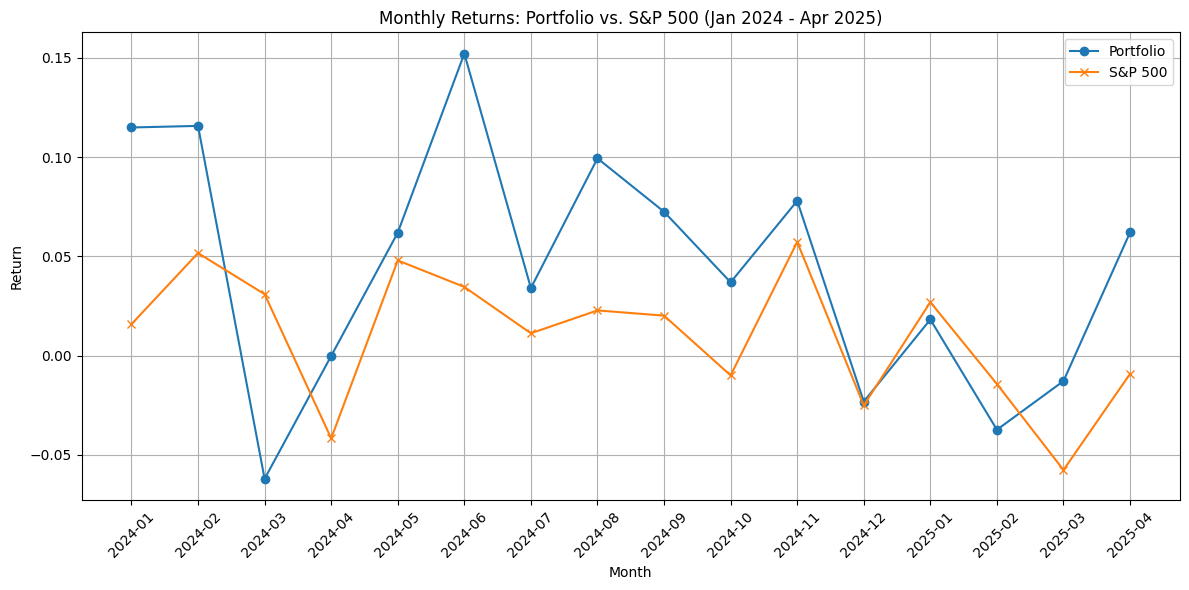

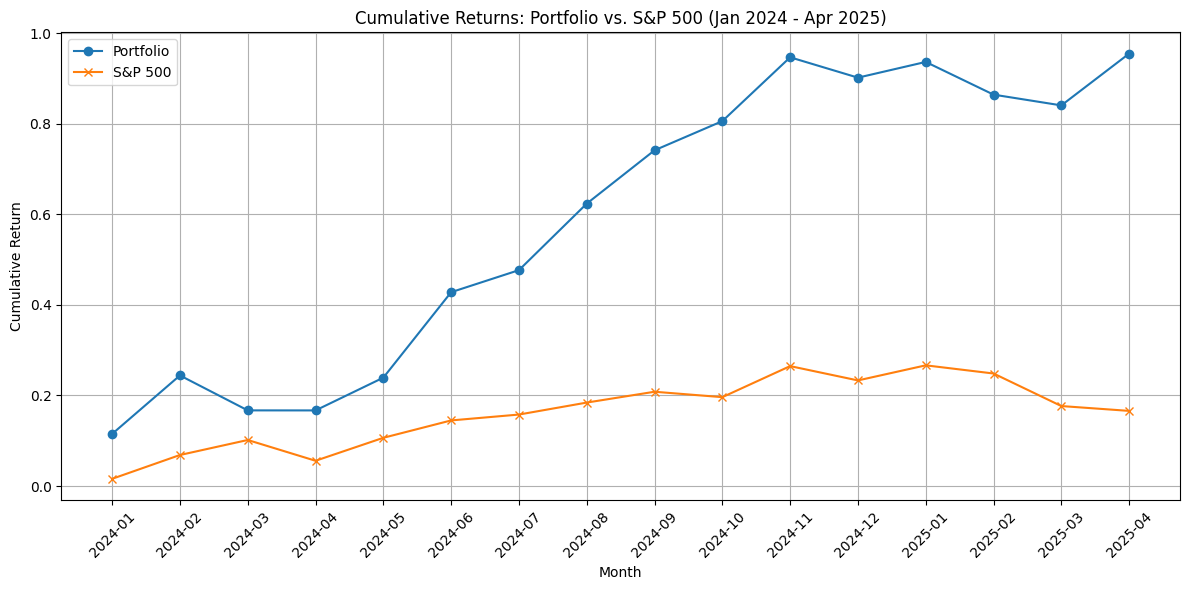

In [26]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

def backtest_portfolio(price_data, portfolio_df):
    monthly_returns = []
    for target_month, group in portfolio_df.groupby('target_month'):
        month_start = pd.to_datetime(target_month + '-01')
        month_end = month_start + pd.offsets.MonthEnd(0)
        trading_dates = price_data.index[(price_data.index >= month_start) & (price_data.index <= month_end)]
        if len(trading_dates) < 2:
            print(f"Skipping {target_month}: Insufficient trading dates")
            continue
        first_day = trading_dates[0]
        last_day = trading_dates[-1]
        long_tickers = group[group['position'] == 'long']['ticker'].tolist()
        short_tickers = group[group['position'] == 'short']['ticker'].tolist()
        long_return = price_data[long_tickers].loc[last_day] / price_data[long_tickers].loc[first_day] - 1
        long_return = long_return.mean() if long_tickers else 0
        short_return = price_data[short_tickers].loc[last_day] / price_data[short_tickers].loc[first_day] - 1
        short_return = short_return.mean() if short_tickers else 0
        portfolio_return = long_return - short_return
        monthly_returns.append({
            'target_month': target_month,
            'long_return': long_return,
            'short_return': short_return,
            'portfolio_return': portfolio_return
        })
    return pd.DataFrame(monthly_returns)

# Load price data
price_data = pd.read_csv('/content/drive/MyDrive/Next-month/price_data.csv', index_col='Date', parse_dates=True)

# Validation backtest
for i in range(2):
    portfolio_df_val = pd.read_csv(f'/content/drive/MyDrive/Next-month/portfolio_val_{i+1}.csv')
    returns_df_val = backtest_portfolio(price_data, portfolio_df_val)
    returns_df_val.to_csv(f'/content/drive/MyDrive/Next-month/returns_val_{i+1}.csv', index=False)
    print(f"Saved returns for validation period {i+1}")

# Backtest period
portfolio_df_backtest = pd.read_csv('/content/drive/MyDrive/Next-month/portfolio_backtest.csv')
returns_df_backtest = backtest_portfolio(price_data, portfolio_df_backtest)
if returns_df_backtest.empty:
    print("Error: No returns generated for backtest period")
else:
    returns_df_backtest.to_csv('/content/drive/MyDrive/Next-month/returns_backtest.csv', index=False)
    print("Saved returns for backtest period")

    # Benchmark comparison
    sp500 = yf.download('^GSPC', start='2023-12-01', end='2025-04-30', auto_adjust=True)['Close']
    sp500_monthly = sp500.resample('M').last().pct_change().dropna()
    sp500_df = sp500_monthly.reset_index()
    sp500_df.columns = ['date', 'sp500_return']
    sp500_df['target_month'] = sp500_df['date'].dt.strftime('%Y-%m')
    sp500_df = sp500_df[sp500_df['target_month'].between('2024-01', '2025-04')]  # Include 2024 and 2025
    merged_df = returns_df_backtest.merge(sp500_df[['target_month', 'sp500_return']], on='target_month', how='left')
    merged_df.to_csv('/content/drive/MyDrive/Next-month/returns_backtest_with_benchmark.csv', index=False)
    print("Saved backtest returns with benchmark")

    # Monthly return plot
    plt.figure(figsize=(12, 6))
    plt.plot(merged_df['target_month'], merged_df['portfolio_return'], marker='o', label='Portfolio')
    plt.plot(merged_df['target_month'], merged_df['sp500_return'], marker='x', label='S&P 500')
    plt.title('Monthly Returns: Portfolio vs. S&P 500 (Jan 2024 - Apr 2025)')
    plt.xlabel('Month')
    plt.ylabel('Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Next-month/backtest_plot.png')

    # Cumulative return plot
    merged_df['portfolio_cum_return'] = (1 + merged_df['portfolio_return']).cumprod() - 1
    merged_df['sp500_cum_return'] = (1 + merged_df['sp500_return']).cumprod() - 1
    plt.figure(figsize=(12, 6))
    plt.plot(merged_df['target_month'], merged_df['portfolio_cum_return'], marker='o', label='Portfolio')
    plt.plot(merged_df['target_month'], merged_df['sp500_cum_return'], marker='x', label='S&P 500')
    plt.title('Cumulative Returns: Portfolio vs. S&P 500 (Jan 2024 - Apr 2025)')
    plt.xlabel('Month')
    plt.ylabel('Cumulative Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Next-month/cumulative_backtest_plot.png')

[*********************100%***********************]  1 of 1 completed

Saved returns for validation period 1
Saved returns for validation period 2
Saved returns for backtest period

Performance Metrics:
 portfolio_annualized_return  portfolio_annualized_volatility  portfolio_sharpe_ratio  portfolio_max_monthly_drawdown  sp500_annualized_return  sp500_annualized_volatility  sp500_sharpe_ratio  sp500_max_monthly_drawdown
                    0.653076                         0.211508                 3.08772                        0.062001                  0.12196                     0.116162            1.049913                    0.057545
Saved performance metrics
Saved backtest returns with benchmark


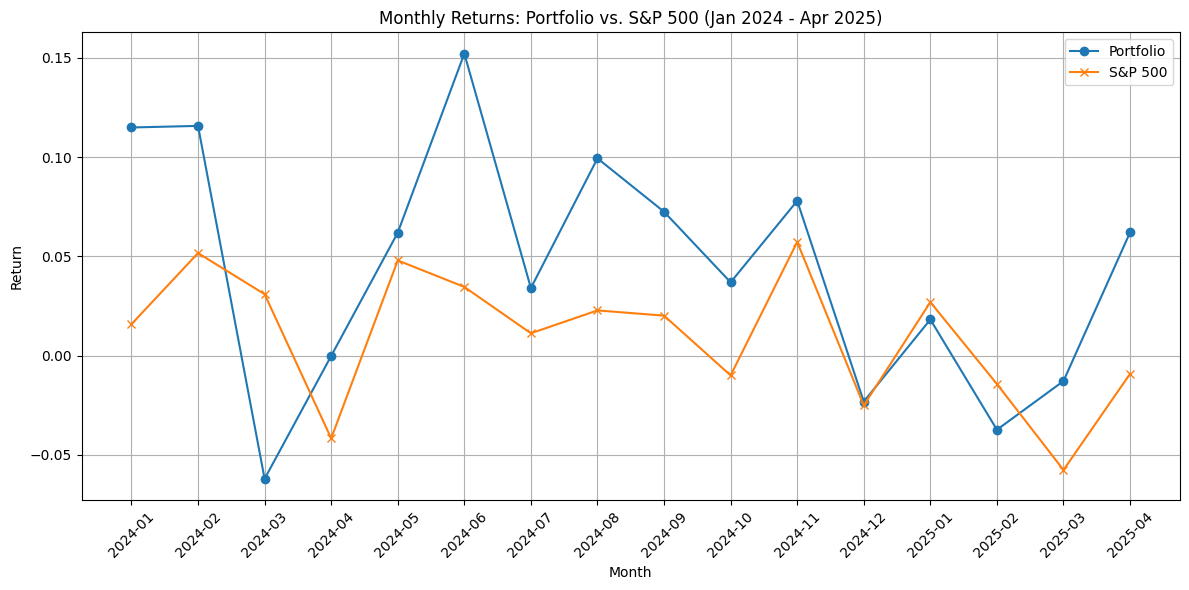

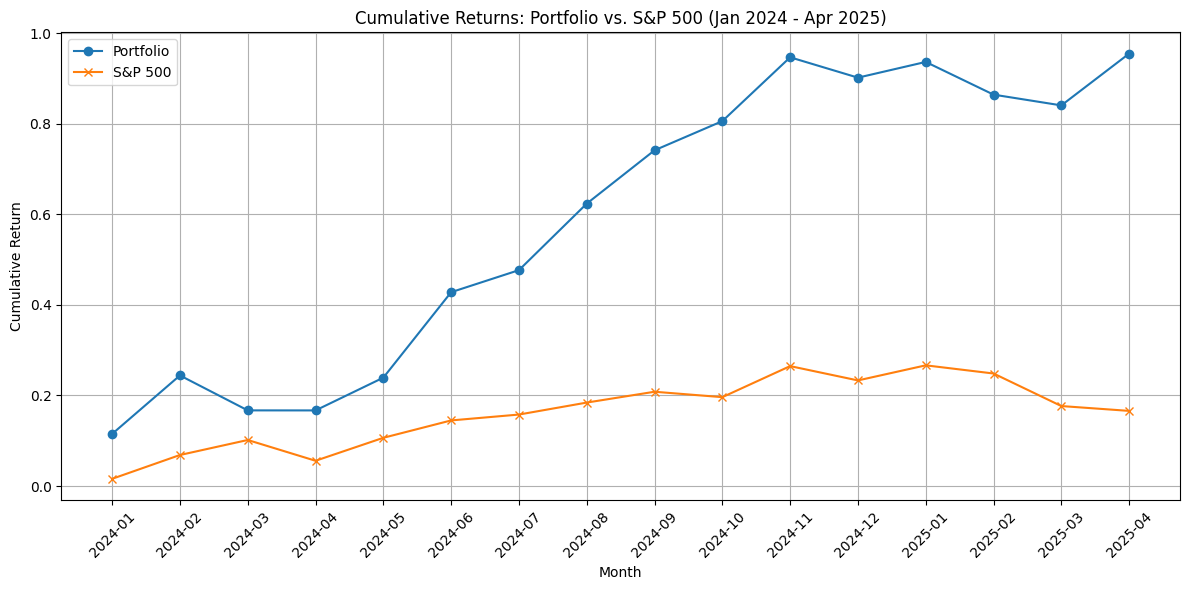

In [29]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

def backtest_portfolio(price_data, portfolio_df):
    monthly_returns = []
    for target_month, group in portfolio_df.groupby('target_month'):
        month_start = pd.to_datetime(target_month + '-01')
        month_end = month_start + pd.offsets.MonthEnd(0)
        trading_dates = price_data.index[(price_data.index >= month_start) & (price_data.index <= month_end)]
        if len(trading_dates) < 2:
            print(f"Skipping {target_month}: Insufficient trading dates")
            continue
        first_day = trading_dates[0]
        last_day = trading_dates[-1]
        long_tickers = group[group['position'] == 'long']['ticker'].tolist()
        short_tickers = group[group['position'] == 'short']['ticker'].tolist()
        long_return = price_data[long_tickers].loc[last_day] / price_data[long_tickers].loc[first_day] - 1
        long_return = long_return.mean() if long_tickers else 0
        short_return = price_data[short_tickers].loc[last_day] / price_data[short_tickers].loc[first_day] - 1
        short_return = short_return.mean() if short_tickers else 0
        portfolio_return = long_return - short_return
        monthly_returns.append({
            'target_month': target_month,
            'long_return': long_return,
            'short_return': short_return,
            'portfolio_return': portfolio_return
        })
    return pd.DataFrame(monthly_returns)

def calculate_performance_metrics(returns, cum_returns, name):
    metrics = {}
    n_months = len(returns)

    # Annualized Return
    if n_months > 0:
        cum_product = np.prod(1 + returns)
        metrics['annualized_return'] = cum_product ** (12 / n_months) - 1
    else:
        metrics['annualized_return'] = np.nan

    # Annualized Volatility
    if n_months > 1:
        monthly_vol = np.std(returns, ddof=1)
        metrics['annualized_volatility'] = monthly_vol * np.sqrt(12)
    else:
        metrics['annualized_volatility'] = np.nan

    # Sharpe Ratio (assuming risk-free rate = 0%)
    if metrics['annualized_volatility'] != 0 and not np.isnan(metrics['annualized_volatility']):
        metrics['sharpe_ratio'] = metrics['annualized_return'] / metrics['annualized_volatility']
    else:
        metrics['sharpe_ratio'] = np.nan

    # Max Monthly Drawdown
    if len(cum_returns) > 1:
        drawdowns = []
        for t in range(1, len(cum_returns)):
            prev_cum = cum_returns.iloc[t-1]
            curr_cum = cum_returns.iloc[t]
            drawdown = (prev_cum - curr_cum) / (1 + prev_cum)
            drawdowns.append(drawdown)
        metrics['max_monthly_drawdown'] = max(drawdowns) if drawdowns else 0
    else:
        metrics['max_monthly_drawdown'] = np.nan

    return {f"{name}_{key}": metrics[key] for key in metrics}

# Load price data
price_data = pd.read_csv('/content/drive/MyDrive/Next-month/price_data.csv', index_col='Date', parse_dates=True)

# Validation backtest
for i in range(2):
    portfolio_df_val = pd.read_csv(f'/content/drive/MyDrive/Next-month/portfolio_val_{i+1}.csv')
    returns_df_val = backtest_portfolio(price_data, portfolio_df_val)
    returns_df_val.to_csv(f'/content/drive/MyDrive/Next-month/returns_val_{i+1}.csv', index=False)
    print(f"Saved returns for validation period {i+1}")

# Backtest period
portfolio_df_backtest = pd.read_csv('/content/drive/MyDrive/Next-month/portfolio_backtest.csv')
returns_df_backtest = backtest_portfolio(price_data, portfolio_df_backtest)
if returns_df_backtest.empty:
    print("Error: No returns generated for backtest period")
else:
    returns_df_backtest.to_csv('/content/drive/MyDrive/Next-month/returns_backtest.csv', index=False)
    print("Saved returns for backtest period")

    # Benchmark comparison
    sp500 = yf.download('^GSPC', start='2023-12-01', end='2025-04-30', auto_adjust=True)['Close']
    sp500_monthly = sp500.resample('M').last().pct_change().dropna()
    sp500_df = sp500_monthly.reset_index()
    sp500_df.columns = ['date', 'sp500_return']
    sp500_df['target_month'] = sp500_df['date'].dt.strftime('%Y-%m')
    sp500_df = sp500_df[sp500_df['target_month'].between('2024-01', '2025-04')]  # Include 2024 and 2025
    merged_df = returns_df_backtest.merge(sp500_df[['target_month', 'sp500_return']], on='target_month', how='left')

    # Compute cumulative returns before metrics
    merged_df['portfolio_cum_return'] = (1 + merged_df['portfolio_return']).cumprod() - 1
    merged_df['sp500_cum_return'] = (1 + merged_df['sp500_return']).cumprod() - 1

    # Calculate performance metrics
    portfolio_metrics = calculate_performance_metrics(
        merged_df['portfolio_return'], merged_df['portfolio_cum_return'], 'portfolio'
    )
    sp500_metrics = calculate_performance_metrics(
        merged_df['sp500_return'], merged_df['sp500_cum_return'], 'sp500'
    )
    metrics_df = pd.DataFrame([portfolio_metrics | sp500_metrics])
    metrics_df.to_csv('/content/drive/MyDrive/Next-month/performance_metrics.csv', index=False)
    print("\nPerformance Metrics:")
    print(metrics_df.to_string(index=False))
    print("Saved performance metrics")

    # Save backtest returns with benchmark
    merged_df.to_csv('/content/drive/MyDrive/Next-month/returns_backtest_with_benchmark.csv', index=False)
    print("Saved backtest returns with benchmark")

    # Monthly return plot
    plt.figure(figsize=(12, 6))
    plt.plot(merged_df['target_month'], merged_df['portfolio_return'], marker='o', label='Portfolio')
    plt.plot(merged_df['target_month'], merged_df['sp500_return'], marker='x', label='S&P 500')
    plt.title('Monthly Returns: Portfolio vs. S&P 500 (Jan 2024 - Apr 2025)')
    plt.xlabel('Month')
    plt.ylabel('Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Next-month/backtest_plot.png')

    # Cumulative return plot
    plt.figure(figsize=(12, 6))
    plt.plot(merged_df['target_month'], merged_df['portfolio_cum_return'], marker='o', label='Portfolio')
    plt.plot(merged_df['target_month'], merged_df['sp500_cum_return'], marker='x', label='S&P 500')
    plt.title('Cumulative Returns: Portfolio vs. S&P 500 (Jan 2024 - Apr 2025)')
    plt.xlabel('Month')
    plt.ylabel('Cumulative Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Next-month/cumulative_backtest_plot.png')

Part 6: Predict Next Month's Portfolio

In [21]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib

# File paths
features_path = '/content/drive/MyDrive/Next-month/features_data.csv'
price_data_path = '/content/drive/MyDrive/Next-month/price_data.csv'

# Load data
features_df = pd.read_csv(features_path)
features_df['date'] = pd.to_datetime(features_df['date'])
price_data = pd.read_csv(price_data_path, index_col='Date', parse_dates=True)

# Predict for 2025-05 using the second model
prediction_month = '2025-05'
pred_date = price_data.index[price_data.index < pd.to_datetime(prediction_month + '-01')].max()

# Check if pred_date is valid
if pd.isna(pred_date):
    print(f"Error: No valid prediction date found before {prediction_month}-01")
else:
    scaler = joblib.load('/content/drive/MyDrive/Next-month/scaler_2.joblib')
    lr_model = joblib.load('/content/drive/MyDrive/Next-month/lr_model_2.joblib')
    knn_model = joblib.load('/content/drive/MyDrive/Next-month/knn_model_2.joblib')
    lstm_model = load_model('/content/drive/MyDrive/Next-month/lstm_model_2.h5')

    pred_df = features_df[features_df['date'] == pred_date].copy()

    # Check if pred_df is not empty
    if pred_df.empty:
        print(f"Error: No feature data available for prediction date {pred_date}")
    else:
        feature_cols = [col for col in pred_df.columns if col not in ['ticker', 'date', 'historical_return']]
        X_pred = pred_df[feature_cols].values
        X_pred_scaled = scaler.transform(X_pred)
        lr_pred = lr_model.predict(X_pred_scaled)
        knn_pred = knn_model.predict(X_pred_scaled)
        X_pred_lstm = X_pred_scaled.reshape((X_pred_scaled.shape[0], 1, X_pred_scaled.shape[1]))
        lstm_pred = lstm_model.predict(X_pred_lstm, verbose=0).flatten()
        ensemble_pred = (lr_pred + knn_pred + lstm_pred) / 3
        pred_df['ensemble_pred'] = ensemble_pred
        pred_df['target_month'] = prediction_month

        # Select portfolio
        long_candidates = pred_df[(pred_df['above_sma200'] == 1) & (pred_df['roe'] > 0.20) & (pred_df['debt_to_equity'] < 1)]
        short_candidates = pred_df[(pred_df['above_sma200'] == 0) & (pred_df['roe'] < 0.10) & (pred_df['debt_to_equity'] > 2)]
        long_stocks = long_candidates.sort_values('ensemble_pred', ascending=False).head(20)[['ticker', 'ensemble_pred']]
        long_stocks['position'] = 'long'
        short_stocks = short_candidates.sort_values('ensemble_pred', ascending=True).head(20)[['ticker', 'ensemble_pred']]
        short_stocks['position'] = 'short'
        portfolio_2025_05 = pd.concat([long_stocks, short_stocks])
        portfolio_2025_05['target_month'] = prediction_month

        # Check if portfolio is not empty
        if portfolio_2025_05.empty:
            print(f"Warning: No stocks selected for {prediction_month} portfolio")
        else:
            portfolio_2025_05.to_csv('/content/drive/MyDrive/Next-month/portfolio_2025_05.csv', index=False)
            print("Saved portfolio for 2025-05")
            print("Long Tickers:", portfolio_2025_05[portfolio_2025_05['position'] == 'long']['ticker'].tolist())
            print("Short Tickers:", portfolio_2025_05[portfolio_2025_05['position'] == 'short']['ticker'].tolist())

Saved portfolio for 2025-05
Long Tickers: ['TPL']
Short Tickers: ['AMD', 'LHX', 'SRE', 'BXP', 'FIS', 'DLR', 'STZ', 'JNPR', 'DIS', 'MHK', 'HRL', 'SWK', 'TYL', 'MDT', 'ADM', 'J', 'COO', 'D', 'BALL', 'AVB']
